### Visualizations


*PLACEHOLDER:*
- Hypothesis Test: Player Churn by Last Event Type
- Hypothesis Test: Player Churn by Stage ID

In [2]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
print("All libraries are working!")

All libraries are working!


In [3]:
#import cleaned data
df_cleaned = pd.read_csv('../data/processed_data/cleaned_player_data.csv')

#### Player Plots

Text(0.5, 1.0, 'Count of events by Player Type')

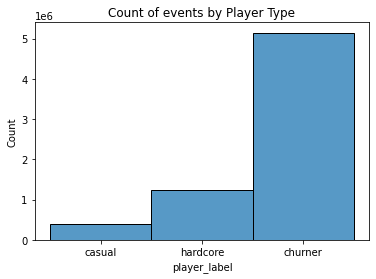

In [4]:
sns.histplot(data=df_cleaned, x='player_label')
plt.title("Count of events by Player Type")

player_label
casual       1806
churner     33523
hardcore     1938
Name: player_id, dtype: int64


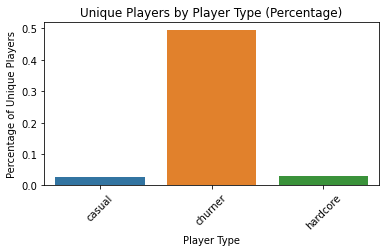

In [ ]:
# Count of unique players by player label 
unique_players = df_cleaned.groupby('player_label')['player_id'].nunique()
print(unique_players)
#plot unique players by player label with percentage
plt.figure(figsize=(6, 3))
sns.barplot(x=unique_players.index, y=unique_players.values / len(df_cleaned) * 100)
plt.title("Unique Players by Player Type (Percentage)")
plt.xlabel("Player Type")
plt.ylabel("Percentage of Unique Players")
plt.xticks(rotation=45)
plt.show()

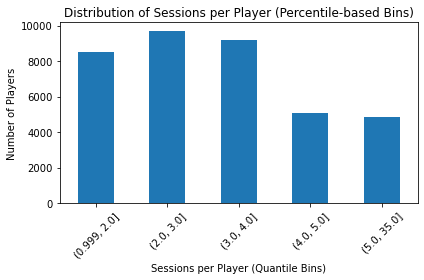

In [ ]:
# Drop duplicates so each player is counted once
player_sessions = df_cleaned.drop_duplicates('player_id')['sessions_per_player']

# Create 5 percentile-based bins (quintiles as example)
sessions_bins = pd.qcut(player_sessions, q=5)

# Count players in each bin
sessions_dist = sessions_bins.value_counts().sort_index()

# Plot
sessions_dist.plot(kind='bar')
plt.xlabel('Sessions per Player (Quantile Bins)')
plt.ylabel('Number of Players')
plt.title('Distribution of Sessions per Player (Percentile-based Bins)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

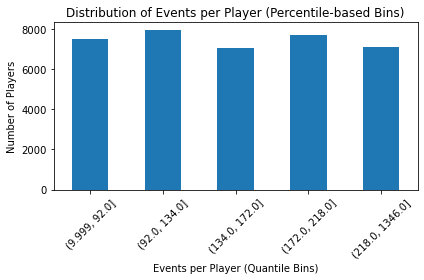

In [ ]:
# Drop duplicates so each player is counted once
player_events = df_cleaned.drop_duplicates('player_id')['events_per_player']

# Create 5 percentile-based bins (quintiles as example)
events_bins = pd.qcut(player_events, q=5)

# Count players in each bin
event_dist = events_bins.value_counts().sort_index()

# Plot
event_dist.plot(kind='bar')
plt.xlabel('Events per Player (Quantile Bins)')
plt.ylabel('Number of Players')
plt.title('Distribution of Events per Player (Percentile-based Bins)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Events Plots

Text(0, 0.5, 'Number of Events')

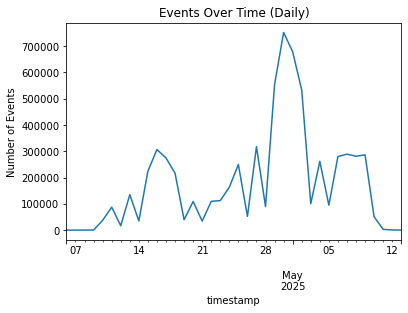

In [ ]:
#Events by day
df_cleaned.set_index('timestamp')['event_type'].resample('D').count().plot()
plt.title("Events Over Time (Daily)")
plt.ylabel("Number of Events")

Text(0, 0.5, 'Number of Events')

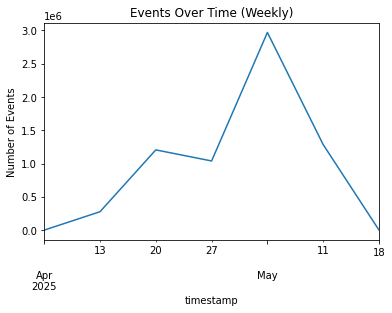

In [ ]:
# Events by Week
df_cleaned.set_index('timestamp')['event_type'].resample('W').count().plot()
plt.title("Events Over Time (Weekly)")
plt.ylabel("Number of Events")

Text(0.5, 0, 'Hour (0 = Midnight)')

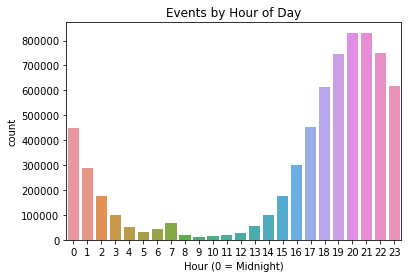

In [ ]:
order = list(range(0, 24))
df_cleaned['hour'] = df_cleaned['hour'].astype(int)
sns.countplot(data=df_cleaned, x='hour', order=order, )
plt.title("Events by Hour of Day")
plt.xlabel("Hour (0 = Midnight)")

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Sunday'),
  Text(1, 0, 'Monday'),
  Text(2, 0, 'Tuesday'),
  Text(3, 0, 'Wednesday'),
  Text(4, 0, 'Thursday'),
  Text(5, 0, 'Friday'),
  Text(6, 0, 'Saturday')])

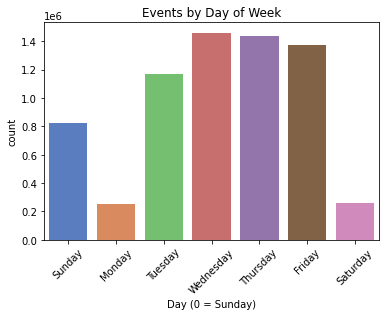

In [ ]:
# Events by day of week
order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
sns.countplot(data=df_cleaned, x='weekday', palette='muted', order=order)
plt.title("Events by Day of Week")
plt.xlabel("Day (0 = Sunday)")
plt.xticks(rotation=45)

event_type    BEGIN_SESSION  BEGIN_STAGE  END_SESSION  END_STAGE
player_label                                                    
casual             3.015009    46.984991     3.015009  46.984991
churner            2.223120    47.776880     2.223120  47.776880
hardcore           2.620671    47.379329     2.620671  47.379329


<Figure size 720x432 with 0 Axes>

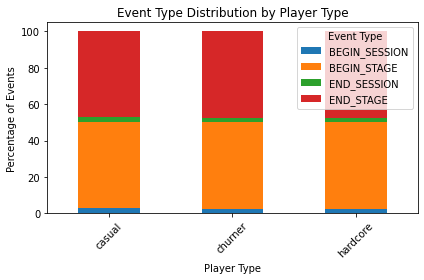

In [ ]:
# plot events by player label percentage  
event_type_by_player_label = df_cleaned.groupby('player_label')['event_type'].value_counts(normalize=True).unstack().fillna(0) * 100
print(event_type_by_player_label)
# Plot
plt.figure(figsize=(10, 6))
event_type_by_player_label.plot(kind='bar', stacked=True)
plt.title("Event Type Distribution by Player Type")
plt.xlabel("Player Type")
plt.ylabel("Percentage of Events")
plt.legend(title='Event Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(event_type_counts)

               stage_score      week       day  events_per_session  \
player_label                                                         
casual        1.231394e+08   6855919   5212176            16331536   
churner       1.538553e+09  89686577  81246982           240509996   
hardcore      4.755664e+08  22363209  16611549            65204116   

              sessions_per_player  events_per_player  
player_label                                          
casual                    2849992           97395488  
churner                  20070232          911989604  
hardcore                 24181136          928724212  


#### Cohort Plots

In [ ]:
# cohort representation over time
df_cleaned['week'] = df_cleaned['timestamp'].dt.strftime('%U')
#make a catplot showing top 3 cohorts for each week of the month

weekly_counts = df_cleaned.groupby(['week', 'cohort_id'])['player_id'].count().reset_index()

weekly_counts.columns = ['week', 'cohort_id', 'event_count']

top3 = weekly_counts.sort_values(['week', 'event_count'], ascending=[True, False])
top3 = top3.groupby('week').head(3)


In [ ]:
top3 = top3.groupby(['week', 'cohort_id']).sum()

In [ ]:

sns.catplot(data=top3, kind='bar', x='week', y='event_count', hue='cohort_id')

#make a catplot showing top 3 cohorts for each day of the week 

#make a catplot showing top 3 cohorts for each hour of the day 


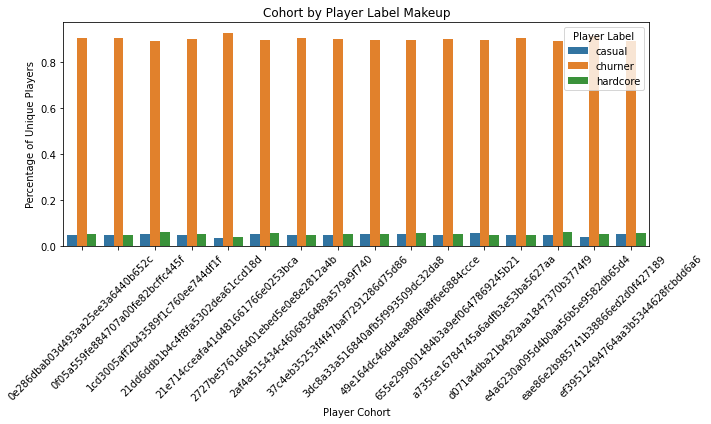

In [ ]:
# cohorts by player label makeup
# cohort by player label makeup
cohort_counts = df_cleaned.groupby(['player_cohort', 'player_label'])['player_id'].nunique().reset_index()
cohort_counts.columns = ['player_cohort', 'player_label', 'unique_players']
cohort_counts = cohort_counts.pivot(index='player_cohort', columns='player_label', values='unique_players')
cohort_counts = cohort_counts.fillna(0)
cohort_counts = cohort_counts.div(cohort_counts.sum(axis=1), axis=0)
cohort_counts = cohort_counts.reset_index()
cohort_counts = cohort_counts.melt(id_vars='player_cohort', var_name='player_label', value_name='percentage')
plt.figure(figsize=(10, 6))
sns.barplot(data=cohort_counts, x='player_cohort', y='percentage', hue='player_label')
plt.title("Cohort by Player Label Makeup")
plt.xlabel("Player Cohort")
plt.ylabel("Percentage of Unique Players")
plt.legend(title='Player Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Misc. Plots

In [ ]:
unique_players_by_type = df_cleaned.groupby('player_type')['player_id'].nunique()

In [ ]:
print(unique_players_by_type)

In [ ]:
unique_players_by_cohort = df_cleaned.groupby('cohort_id')['player_id'].nunique()


In [ ]:
#target label
print("Target label raw counts:\n", df_cleaned['player_type'].value_counts())
print("\nTarget label percentages:\n", df_cleaned['player_type'].value_counts(normalize=True))

In [ ]:
df_cleaned.columns

In [ ]:
# view player type by cohort
type_by_cohort = df_cleaned.groupby(['cohort_id', 'player_type'])['session_id'].count()


In [ ]:
type_by_cohort

In [ ]:
pivot = df_cleaned.pivot_table(
    index='cohort_id',
    columns='player_type',
    values='player_id',
    aggfunc='nunique',   # Or 'count' if each row = 1 player
    fill_value=0         # Optional: replace NaNs with 0s
)

In [ ]:
pivot